In [1]:
from __future__ import annotations

from dataclasses import dataclass

import petsc4py.PETSc as PETSc
import numpy as np
from ufl import det, tr

from homicsx import(
    Inclusion,
    RVEGeometry, 
    PhysicalTags, 
    MeshSettings,
    MaterialAssignment,
    ProblemSettings,
)
from homicsx.core.material import HyperelasticMaterial, MaterialState
from homicsx.mesh import generate_mesh
from homicsx.core.homogenization import AdaptiveSettings
from homicsx.homogenization.driver import (
    NonlinearHomogenizationDriver,
    PostLoadCaseData,
    PreStepData,
    PostStressData,
)

In [2]:
# ------------------------------------------------------------------------------
# Mesh Generation
# ------------------------------------------------------------------------------
dim = 2
domain_size = (1, 1)

inclusion = Inclusion(
    center=[0.5, 0.5],
    phase_id=1,
    shape='circle',
    radii=0.2,
)

geometry = RVEGeometry(
    dim=dim,
    domain_size=domain_size,
    inclusions=[inclusion],
)

physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.02,
    max_size=0.04,
    physical_tags=physical_tags,
    quad_hex=True,
)

domain, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

# ------------------------------------------------------------------------------
# Material assignment
# ------------------------------------------------------------------------------
@dataclass
class NeoHookeanDecoupled(HyperelasticMaterial):
    def __init__(self, kappa, mu):
        self.kappa = kappa
        self.mu = mu
    
    def psi_form(self, F):
        F.ufl_shape[0]
        C = F.T * F
        J = det(F)
        I1 = J**(-2/3) * (tr(C) + 1)
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)
    
    def evaluate_energy(self, F: np.ndarray, dim: int) -> float:
        """Numeric evaluation matching psi_form."""
        J = np.linalg.det(F)
        C = F.T @ F
        tr_C = np.trace(C)
        if dim == 2:
            I1 = J**(-2/3) * (tr_C + 1)
        else:
            I1 = J**(-2/3) * tr_C
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)
    
    def get_quadrature_point_stress(self, state: MaterialState, F: np.ndarray, quad_point_idx: int) -> np.ndarray:
        F.shape[0]
        J = np.linalg.det(F)
        Finv = np.linalg.inv(F)
        FinvT = Finv.T
        
        C = F.T @ F
        tr_C = np.trace(C)
        
        P_iso = self.mu * J**(-2.0/3.0) * (F - (1.0/3.0) * tr_C * FinvT)
        P_vol = self.kappa * J * (J - 1.0) * FinvT
        
        return P_iso + P_vol

kappa_mat = 2.0
mu_mat = 0.5
mat_matrix = NeoHookeanDecoupled(kappa=kappa_mat, mu=mu_mat)

kappa_inc = 50
mu_inc = 20
mat_inclusion = NeoHookeanDecoupled(kappa=kappa_inc, mu=mu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_inclusion,
    }
)

# ------------------------------------------------------------------------------
# FEM problem settings
# ------------------------------------------------------------------------------
fem_settings = ProblemSettings(
    dim = dim,
    kinematics='finite_strain',
    two_dimensional_formulation='plane_strain',
    element_family='P',
    element_degree=1,
    petsc_options={
        "ksp_type": "gmres",
        "pc_type": "hypre",
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1e-8,
        "snes_atol": 1e-10,
        "snes_max_it": 12,
    }
)

In [3]:
# ------------------------------------------------------------------------------
# DAMAGE HOOK
# ------------------------------------------------------------------------------
matrix_material_ref = mat_matrix  # Direct reference to the matrix material
def hyperelastic_damage_hook(data: PostStressData) -> None:
    """
    Apply damage and track detailed evolution for adaptive stepping.
    """
    state = data.state
    
    damage_threshold = state.get('damage_threshold', 0.02)
    damage_rate = state.get('damage_rate', 15.0)
    max_damage = state.get('max_damage', 0.95)
    
    dim = data.context.metadata['dim']
    
    # Get local deformation gradient
    F_by_cell = data.context.quad_evaluator.compute_deformation_gradient_at_quad_points(
        data.u, data.context.F_macro
    )
    
    # Find maximum local strain
    max_effective_strain = 0.0
    strain_values = []
    
    for cell_idx, F_qp in F_by_cell.items():
        for qp in range(F_qp.shape[0]):
            F = F_qp[qp]
            C = F.T @ F
            E = 0.5 * (C - np.eye(dim))
            
            if dim == 2:
                E_dev = E - (1/3) * np.trace(E) * np.eye(dim)
                equiv_strain = np.sqrt((2/3) * np.sum(E_dev**2))
            else:
                E_dev = E - (1/3) * np.trace(E) * np.eye(dim)
                equiv_strain = np.sqrt((2/3) * np.sum(E_dev**2))
            
            eigenvalues = np.linalg.eigvalsh(E)
            max_principal = np.max(np.abs(eigenvalues))
            effective_strain = max(equiv_strain, max_principal)
            
            strain_values.append(effective_strain)
            if effective_strain > max_effective_strain:
                max_effective_strain = effective_strain
    
    # Compute damage
    if max_effective_strain <= damage_threshold:
        damage = 0.0
    else:
        damage = 1.0 - np.exp(-damage_rate * (max_effective_strain - damage_threshold))
        damage = min(damage, max_damage)
    
    previous_damage = state.get('current_damage', 0.0)
    damage = max(damage, previous_damage)
    
    # Calculate damage rate (change per unit strain)
    damage_change = damage - previous_damage
    load_change = data.current_load - state.get('previous_load', 0.0)
    damage_rate_value = damage_change / max(load_change, 1e-10) if load_change > 0 else 0.0
    
    # Apply damage to material
    if not hasattr(matrix_material_ref, '_original_mu'):
        matrix_material_ref._original_mu = matrix_material_ref.mu
        matrix_material_ref._current_damage = 0.0
    
    if damage > matrix_material_ref._current_damage:
        old_mu = matrix_material_ref.mu
        matrix_material_ref._current_damage = damage
        matrix_material_ref.mu = matrix_material_ref._original_mu * (1.0 - damage)
        
        # Store detailed state for adaptive stepping
        state.set('current_damage', damage)
        state.set('previous_damage', previous_damage)
        state.set('damage_change', damage_change)
        state.set('damage_rate_value', damage_rate_value)
        state.set('max_local_strain', max_effective_strain)
        state.set('mean_local_strain', np.mean(strain_values))
        state.set('std_local_strain', np.std(strain_values))
        state.set('previous_load', data.current_load)
        
        # Track history
        state.append_history('damage_history', damage)
        state.append_history('load_history', data.current_load)
        state.append_history('max_strain_history', max_effective_strain)
        state.append_history('damage_rate_history', damage_rate_value)
        
        # Determine damage phase
        if damage < 0.01:
            phase = "UNDAMAGED"
        elif damage < 0.3:
            phase = "DAMAGE ONSET"
        elif damage < 0.7:
            phase = "DAMAGE EVOLUTION"
        else:
            phase = "NEAR FAILURE"
        
        state.set('damage_phase', phase)
        
        print(f"\n{'='*60}")
        print(f"DAMAGE UPDATE - Step {data.step_idx}, Load={data.current_load:.4f}")
        print(f"{'='*60}")
        print(f"  Phase: {phase}")
        print(f"  Max local strain: {max_effective_strain:.4f}")
        print(f"  Mean local strain: {np.mean(strain_values):.4f} +- {np.std(strain_values):.4f}")
        print(f"  Damage: {previous_damage:.3f} -> {damage:.3f} (delta={damage_change:.3f})")
        print(f"  Matrix mu: {old_mu:.3f} -> {matrix_material_ref.mu:.3f}")
        print(f"{'='*60}\n")
    
    # Always update strain info even if damage didn't change
    state.set('max_local_strain', max_effective_strain)
    state.set('mean_local_strain', np.mean(strain_values))

# ------------------------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------------------------
def final_damage_summary(data: PostLoadCaseData) -> None:
    """Print final damage summary."""
    if hasattr(matrix_material_ref, '_original_mu'):
        original = matrix_material_ref._original_mu
        final = matrix_material_ref.mu
        damage = getattr(matrix_material_ref, '_current_damage', 0.0)
        
        print(f"\n{'='*60}")
        print(f"FINAL DAMAGE SUMMARY")  # noqa: F541
        print(f"{'='*60}")
        print(f"  Original mu: {original:.3f}")
        print(f"  Final mu:    {final:.3f}")
        print(f"  Damage:     {damage:.3f}")
        print(f"  Reduction:  {(1 - final/original)*100:.1f}%")
        print(f"{'='*60}\n")
    else:
        print(f"\n[WARNING] No damage was applied - material unchanged\n")  # noqa: F541

# ------------------------------------------------------------------------------
# SOFTENING DETECTION HOOK - Requests smaller steps during damage evolution
# ------------------------------------------------------------------------------
def adaptive_damage_stepping_hook(data: PreStepData) -> None:
    """
    Monitor damage evolution and request smaller steps when:
    - Damage first appears
    - Damage is rapidly increasing
    - Approaching max damage
    
    This hook MODIFIES the step size by setting force_adaptive_step_reduction.
    """
    state = data.state
    
    # Get damage history
    damage_history = state.get_history('damage_history')
    state.get_history('load_history')
    
    if len(damage_history) < 2:
        # Not enough history yet
        return
    
    current_damage = damage_history[-1]
    previous_damage = damage_history[-2]
    damage_rate = (current_damage - previous_damage) / max(data.load_increment, 1e-10)
    
    # Get parameters
    state.get('damage_threshold', 0.02)
    max_damage = state.get('max_damage', 0.95)
    
    # Track if we've already reduced step in this damage regime
    step_reduced = state.get('step_reduced_for_damage', False)
    damage_onset_detected = state.get('damage_onset_detected', False)
    
    should_reduce = False
    reason = ""
    
    # Condition 1: Damage just started (first appearance)
    if current_damage > 0.01 and previous_damage < 0.01 and not damage_onset_detected:
        should_reduce = True
        reason = "damage onset detected"
        state.set('damage_onset_detected', True)
        state.set('damage_onset_load', data.current_load)
    
    # Condition 2: Rapid damage evolution (high damage rate)
    elif damage_rate > 5.0 and not step_reduced:  # Damage increasing faster than 5.0 per unit strain
        should_reduce = True
        reason = f"rapid damage evolution (rate={damage_rate:.2f})"
        state.set('step_reduced_for_damage', True)
    
    # Condition 3: Approaching max damage (need resolution for near-failure)
    elif current_damage > 0.7 * max_damage and not state.get('near_failure_reduction', False):
        should_reduce = True
        reason = f"approaching max damage"  # noqa: F541
        state.set('near_failure_reduction', True)
    
    # Condition 4: Damage is high but step is still large
    elif current_damage > 0.3 and data.load_increment > 0.03:
        should_reduce = True
        reason = f"high damage regime (damage={current_damage:.2f}, da={data.load_increment:.3f})"
    
    if should_reduce:
        data.force_adaptive_step_reduction = True
        print(f"\n[Hook] STEP REDUCTION REQUESTED: {reason}")
        print(f"[Hook]    Current damage: {current_damage:.3f}")
        print(f"[Hook]    Current step size: {data.load_increment:.2e}")
        
        # Store the reduction event
        state.append_history('step_reduction_events', {
            'step': data.step_idx,
            'load': data.current_load,
            'damage': current_damage,
            'reason': reason
        })
    
    # Reset reduction flags if damage has stabilized
    if damage_rate < 1.0 and current_damage > 0.1:
        state.set('step_reduced_for_damage', False)


STARTING HOMOGENIZATION ANALYSIS
   Dimension: 2D
   Number of load cases: 1
   Max strain: 0.4
   History-dependent materials: False


######################################################################
Load Case 1/1: tension
######################################################################

STARTING LOAD CASE: tension
   Target Load: 0.4000 | Initial da: 2.00e-02

Step   1 | Progress:   5.00% | Load: 0.020000 | da: 2.00e-02
   Strain increment da: 2.00e-02 | Physical dt: 0.00e+00
   Attempting da: 2.00e-02
   SUCCESS: Converged in 3 iterations.
   Stats: Wbar=6.2912e-04 | Jbar=1.0200 | P_max=6.2754e-02

DAMAGE UPDATE - Step 1, Load=0.0200
  Phase: DAMAGE ONSET
  Max local strain: 0.0358
  Mean local strain: 0.0185 +- 0.0108
  Damage: 0.000 -> 0.211 (delta=0.211)
  Matrix mu: 0.500 -> 0.394

   Computing Tangent stiffness...
   Done.
   Increasing step size: 2.00e-02 -> 2.60e-02

Step   2 | Progress:  11.50% | Load: 0.046000 | da: 2.60e-02
   Strain increment da: 2.60e-02 | P

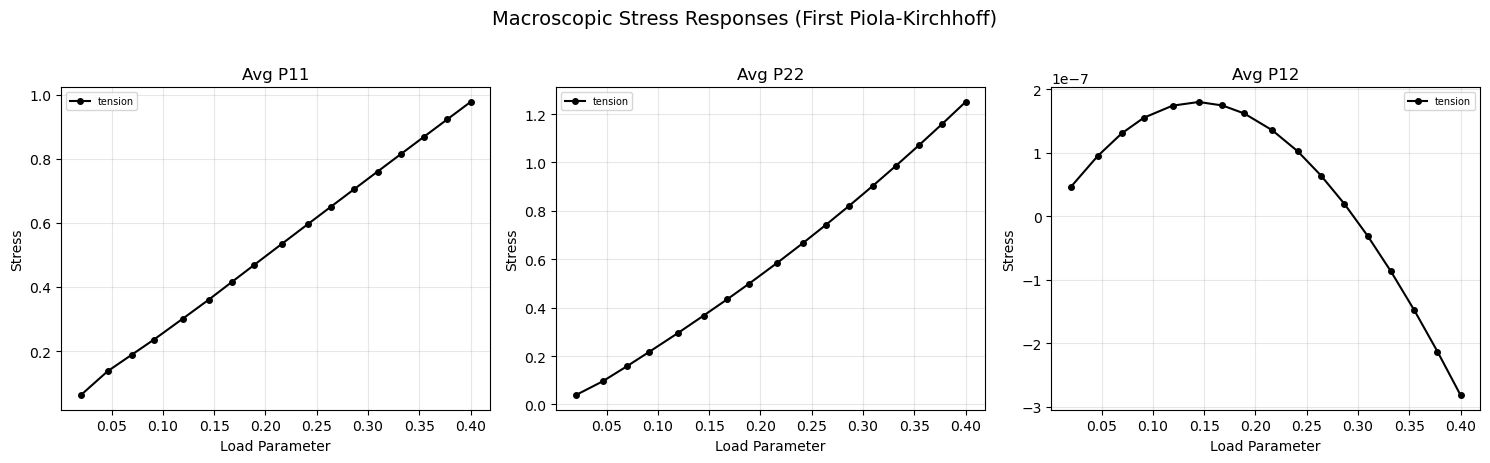

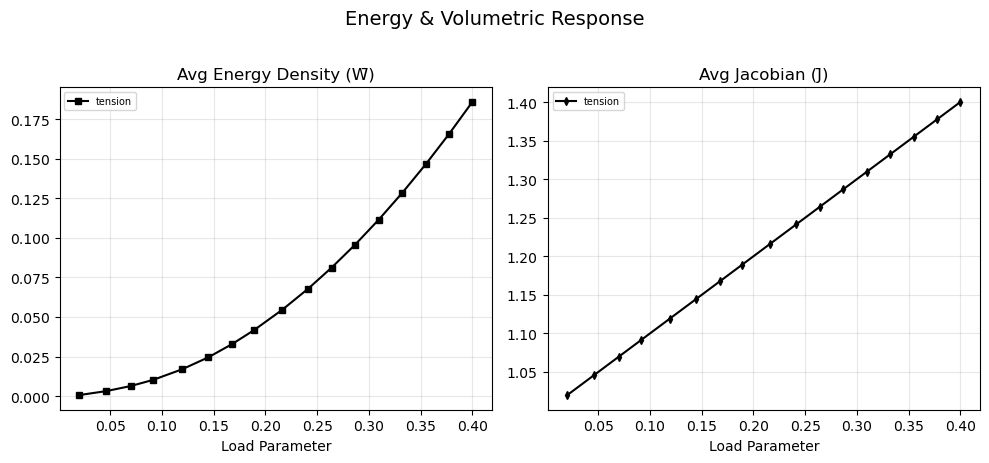

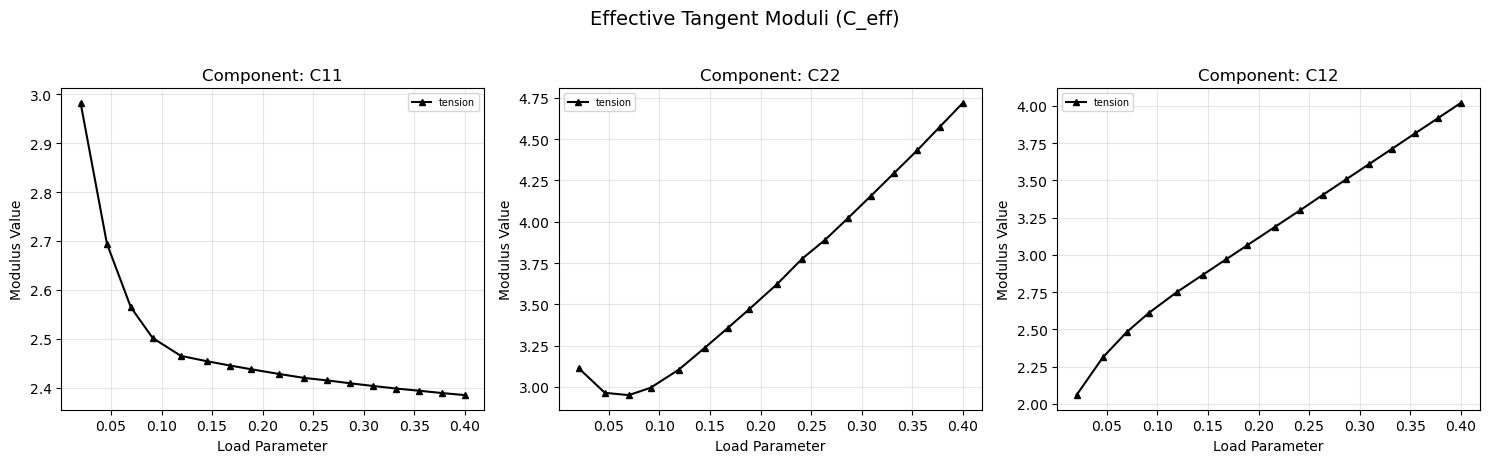

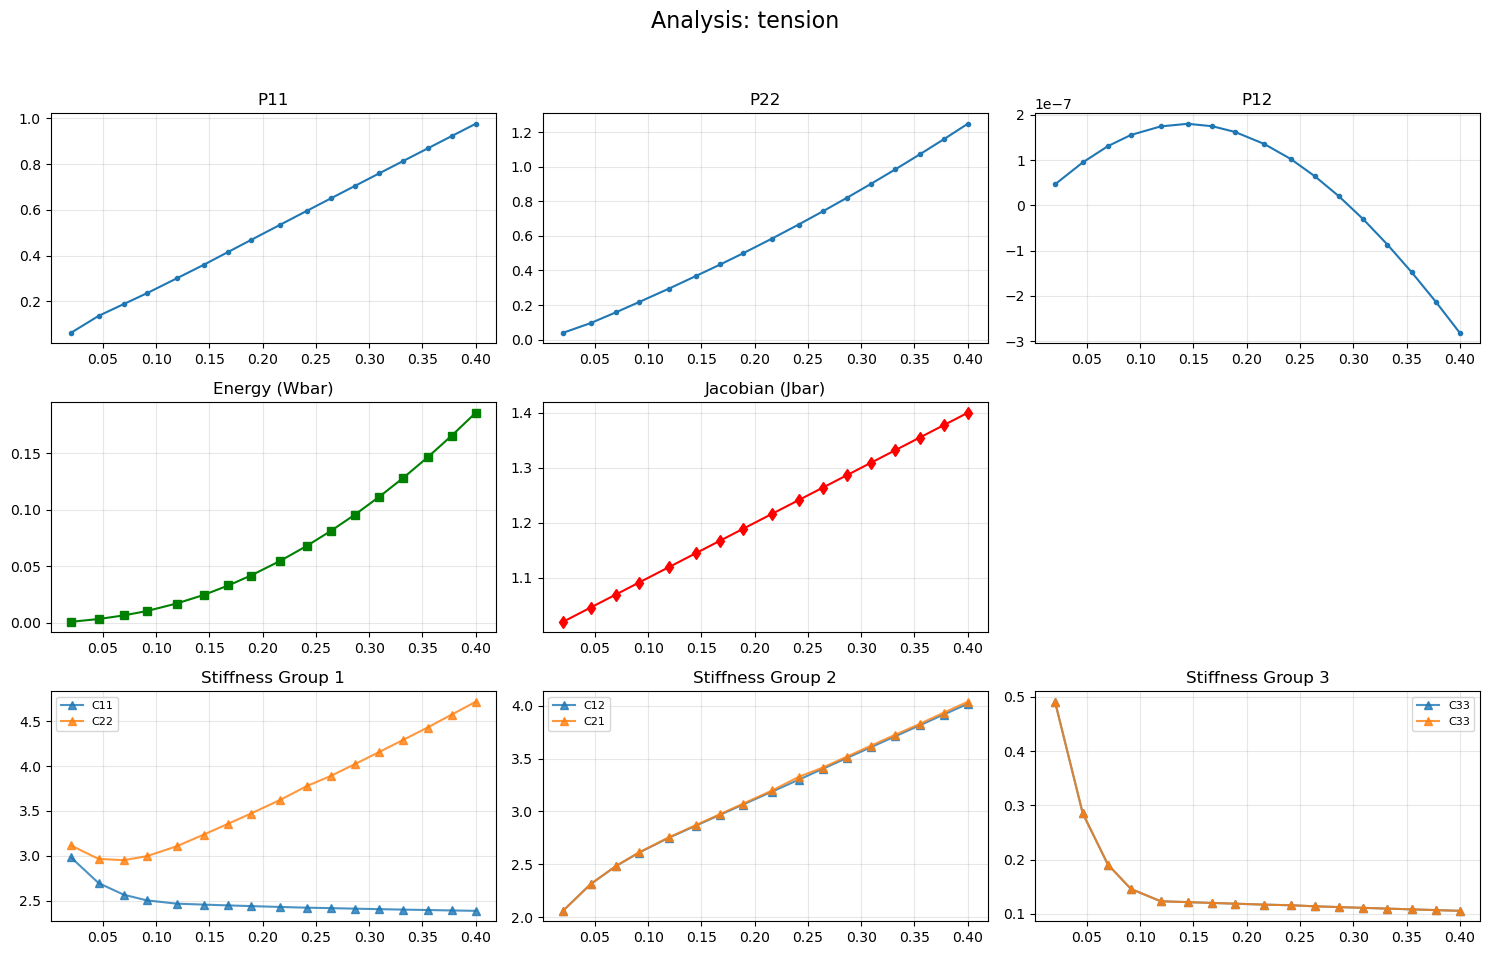

{'tension': {'load': array([0.02      , 0.046     , 0.06966   , 0.0911906 , 0.11918038,
       0.14465108, 0.16782942, 0.1889217 , 0.21634168, 0.24129385,
       0.26400033, 0.28670681, 0.30941329, 0.33211977, 0.35482625,
       0.37753273, 0.4       ]), 'P11': array([0.06275426, 0.1369408 , 0.18864945, 0.23565351, 0.30057   ,
       0.36015218, 0.41693835, 0.4684404 , 0.53516575, 0.59568019,
       0.65059147, 0.70536403, 0.76000733, 0.81452994, 0.86893969,
       0.92324376, 0.97687818]), 'P22': array([0.0388651 , 0.09534203, 0.15756795, 0.21648731, 0.29411892,
       0.36752583, 0.43528916, 0.49908802, 0.5850684 , 0.66630015,
       0.74269765, 0.82145568, 0.90257476, 0.9860553 , 1.07189764,
       1.16010204, 1.24970231]), 'Wbar': array([0.00062912, 0.00312302, 0.00632492, 0.01018239, 0.01685812,
       0.02444906, 0.03289186, 0.04165661, 0.05458999, 0.06786977,
       0.0812038 , 0.09572732, 0.11143939, 0.12833912, 0.14642573,
       0.16569848, 0.185935  ]), 'Jbar': array([1.02  

In [4]:
driver = NonlinearHomogenizationDriver(
    mesh_obj=domain,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=domain_size,
    matrix_phase_id=0,
    quad_degree=4,
    enable_hooks=True,
)

# Set damage parameters
driver.state.set('damage_threshold', 0.02, scope='persistent')
driver.state.set('damage_rate', 15.0, scope='persistent')
driver.state.set('max_damage', 0.95, scope='persistent')

# Initialize state variables
driver.state.set('current_damage', 0.0)
driver.state.set('previous_load', 0.0)
driver.state.set('damage_phase', 'UNDAMAGED')

# Register hooks
driver.add_pre_step_hook(adaptive_damage_stepping_hook)
driver.add_post_stress_hook(hyperelastic_damage_hook)
driver.add_post_load_case_hook(final_damage_summary)

def uni_tension_func(a):
    F = np.eye(2, dtype=PETSc.ScalarType)
    F[0, 0] = 1.0 + a
    return F

result = driver.run(
    tangent_every=1,
    output_prefix='rve',
    max_strain=0.4,
    custom_loads={
        'tension': uni_tension_func,
    },
    from_built_in_loads=[],
    adaptive_settings=AdaptiveSettings(
        initial_step_ratio=0.05,
        min_step= 1e-4,
        target_iters_min=4,
        target_iters_max=8,
        cutback_factor=0.7,
        growth_factor=1.3,
    ),
    xdmf_opt=False,
    csv_opt=False,
    plot_summary=True,
    plot_individual=True,
)

print(result.summary)